# MedJUDGE — Manuscript Figures
**Journal of Biomedical Informatics (JBI) | PICO framework | 1–3 scale | 8 primary judges**

Run from: `/Users/chenyuli/Desktop/MedOS/BMI-Research/rwe-research/`

Each figure is one self-contained cell. Edit fonts, colours, and data directly here.

**Figures for JBI submission:**
- figA: Per-judge mean scores (95% CI)
- figB: PICO dimension scores
- figC: IRR metrics (All / Large / Small)
- figD: Severity calibration (8 primary OSS judges)
- figE: Temperature stability
- figF: Positional bias (2-way, single-judge)
- figF2: Multi-judge positional bias (all judges × 30 papers) ← NEW
- figG: Population label bias
- figH: Scale sensitivity
- figI: Cross-judge score heatmap
- figS: Supplement — Q1 judge variance per extractor

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from statistics import mean, median
from scipy import stats

# ── Absolute paths — works regardless of where notebook is opened ────────────
RWE_ROOT = Path('/Users/chenyuli/Desktop/MedOS/BMI-Research/rwe-research')
BIAS_DIR  = RWE_ROOT / 'AMIA2026_Package/data/bias_results'
CJ_DIR    = RWE_ROOT / 'cross_judge_results'
PICO_DIR  = RWE_ROOT / 'pico_extraction'
OUT_DIR   = RWE_ROOT / 'AMIA2026_Package/manuscript/figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Global font / style — EDIT HERE ─────────────────────────────────────────
FONT_FAMILY  = 'Arial'          # or 'Helvetica', 'DejaVu Sans'
FONT_SIZE    = 10
LABEL_SIZE   = 11
TITLE_SIZE   = 12
TICK_SIZE    = 9
LEGEND_SIZE  = 9
DPI          = 300

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family':       FONT_FAMILY,
    'font.size':         FONT_SIZE,
    'axes.labelsize':    LABEL_SIZE,
    'axes.titlesize':    TITLE_SIZE,
    'xtick.labelsize':   TICK_SIZE,
    'ytick.labelsize':   TICK_SIZE,
    'legend.fontsize':   LEGEND_SIZE,
})

# ── Colour palette — Wong (2011) colorblind-safe, AMIA-ready ────────────────
COL_LARGE  = '#0072B2'   # Wong blue          — large OSS judges (≥27B)
COL_SMALL  = '#D55E00'   # Wong vermilion     — small OSS judges (<10B)
COL_PRIV   = '#CC79A7'   # Wong reddish-purple — proprietary judges
COL_OK     = '#009E73'   # Wong bluish-green  — consistent / correct
COL_FAIL   = '#D55E00'   # Wong vermilion     — inconsistent / fail
COL_WARM   = '#E69F00'   # Wong amber/orange  — warning / moderate
COL_POP    = '#0072B2'   # population bias bars

# ── Model lists ──────────────────────────────────────────────────────────────
LARGE       = ['DeepSeek-V3-685B', 'Kimi-K2-1T', 'Llama-3.3-70B', 'Gemma-3-27B', 'Qwen3-32B']
SMALL       = ['Llama-3.1-8B', 'Llama-3.2-3B', 'Qwen2.5-7B', 'Qwen3-0.6B']
PROPRIETARY = ['Claude-Sonnet-4.6', 'GPT-5.2']
ALL_JUDGES  = LARGE + SMALL
PICO_DIMS   = ['P_accuracy','I_accuracy','C_accuracy','O_accuracy',
                'confounders_accuracy','completeness','overall']

print('Setup complete.')
print('Data root:', RWE_ROOT)
print('Figures →', OUT_DIR)
print(f'Judge groups: Large={len(LARGE)}, Small={len(SMALL)}, Proprietary={len(PROPRIETARY)}')


Setup complete.
Data root: /Users/chenyuli/Desktop/MedOS/BMI-Research/rwe-research
Figures → /Users/chenyuli/Desktop/MedOS/BMI-Research/rwe-research/AMIA2026_Package/manuscript/figures
Judge groups: Large=5, Small=4, Proprietary=2


---
## Figure A — Per-Judge Mean Scores (heatmap + bar)

In [2]:
# ── Load cross-judge data ────────────────────────────────────────────────────
with open(CJ_DIR / 'progress.json') as f:
    cj = json.load(f)

# Build DataFrame: one row per (pmid, extractor, judge, dim, score)
rows = []
for pmid, exts in cj.items():
    for ext, judges in exts.items():
        for judge, data in judges.items():
            if not isinstance(data, dict) or not data.get('success'): continue
            sc = data.get('scores', {})
            for dim in PICO_DIMS:
                v = sc.get(dim)
                if isinstance(v, (int, float)) and v > 0:
                    rows.append({'pmid': pmid, 'extractor': ext,
                                 'judge': judge, 'dim': dim, 'score': float(v)})
df = pd.DataFrame(rows)
print(f'Loaded {len(df):,} score records | {df.pmid.nunique()} papers | {df.judge.nunique()} judges')
df.head(3)

Loaded 8,367 score records | 30 papers | 11 judges


,pmid,extractor,judge,dim,score
0,20473188,DeepSeek-V3,DeepSeek-V3-685B,P_accuracy,2.0
1,20473188,DeepSeek-V3,DeepSeek-V3-685B,I_accuracy,2.0
2,20473188,DeepSeek-V3,DeepSeek-V3-685B,C_accuracy,2.0


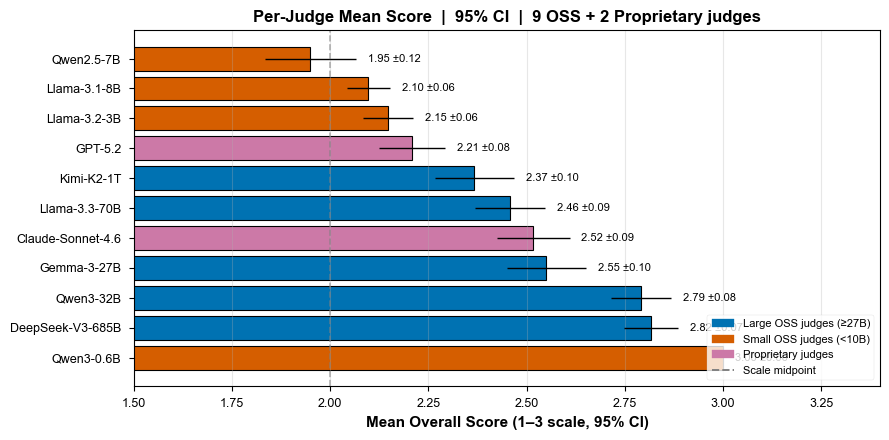

            judge       group     mean     ci95  count
       Qwen3-0.6B       Small 3.000000 0.000000      7
 DeepSeek-V3-685B       Large 2.816667 0.069523    120
        Qwen3-32B       Large 2.790909 0.076344    110
      Gemma-3-27B       Large 2.550000 0.100708    120
Claude-Sonnet-4.6 Proprietary 2.516667 0.092734    120
    Llama-3.3-70B       Large 2.458333 0.089524    120
       Kimi-K2-1T       Large 2.366667 0.100930    120
          GPT-5.2 Proprietary 2.208333 0.083297    120
     Llama-3.2-3B       Small 2.147142 0.063896    120
     Llama-3.1-8B       Small 2.096639 0.055202    119
       Qwen2.5-7B       Small 1.949580 0.116603    119


In [3]:
# ── Figure A: Per-judge mean overall score (95% CI) ──────────────────────────
overall_df = df[df.dim == 'overall'].copy()
judge_means = overall_df.groupby('judge')['score'].agg(['mean','std','count']).reset_index()

def assign_group(j):
    if j in LARGE:       return 'Large'
    if j in PROPRIETARY: return 'Proprietary'
    return 'Small'

judge_means['group'] = judge_means['judge'].apply(assign_group)
judge_means = judge_means.sort_values('mean', ascending=False)

# 95% CI = 1.96 × SE  (SE = std / √n)
judge_means['ci95'] = 1.96 * judge_means['std'] / np.sqrt(judge_means['count'])

fig, ax = plt.subplots(figsize=(9, 4.5))

def bar_color(g):
    if g == 'Large':       return COL_LARGE
    if g == 'Proprietary': return COL_PRIV
    return COL_SMALL

colors = [bar_color(g) for g in judge_means['group']]
bars = ax.barh(judge_means['judge'], judge_means['mean'],
               xerr=judge_means['ci95'], color=colors,
               edgecolor='black', linewidth=0.8, capsize=3, error_kw={'linewidth': 1})

ax.axvline(x=2.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label='Scale midpoint (2.0)')

# Annotate values
for bar, (_, row) in zip(bars, judge_means.iterrows()):
    ax.text(row['mean'] + row['ci95'] + 0.03, bar.get_y() + bar.get_height() / 2,
            f"{row['mean']:.2f} ±{row['ci95']:.2f}",
            va='center', fontsize=8)

ax.legend(handles=[
    mpatches.Patch(color=COL_LARGE, label='Large OSS judges (≥27B)'),
    mpatches.Patch(color=COL_SMALL, label='Small OSS judges (<10B)'),
    mpatches.Patch(color=COL_PRIV,  label='Proprietary judges'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Scale midpoint'),
], fontsize=8, loc='lower right')

n_oss  = len([j for j in judge_means['judge'] if assign_group(j) != 'Proprietary'])
n_priv = len([j for j in judge_means['judge'] if assign_group(j) == 'Proprietary'])
ax.set_xlabel('Mean Overall Score (1–3 scale, 95% CI)', fontweight='bold')
ax.set_title(f'Per-Judge Mean Score  |  95% CI  |  {n_oss} OSS + {n_priv} Proprietary judges',
             fontweight='bold')
ax.set_xlim(1.5, 3.4)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figA_judge_scores.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figA_judge_scores.png', dpi=DPI, bbox_inches='tight')
plt.show()
print(judge_means[['judge','group','mean','ci95','count']].to_string(index=False))


---
## Figure B — Per-PICO Dimension Scores

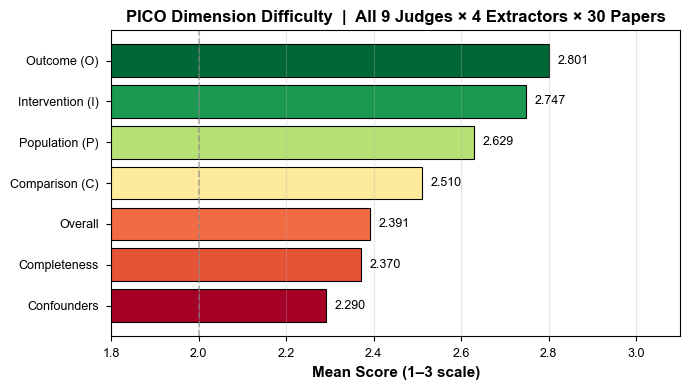

In [4]:
# ── Figure B: Per-PICO dimension mean scores ─────────────────────────────────
# EDIT: dim_labels to change display names
dim_labels = {
    'P_accuracy':           'Population (P)',
    'I_accuracy':           'Intervention (I)',
    'C_accuracy':           'Comparison (C)',
    'O_accuracy':           'Outcome (O)',
    'confounders_accuracy': 'Confounders',
    'completeness':         'Completeness',
    'overall':              'Overall',
}

dim_means = df.groupby('dim')['score'].mean().reset_index()
dim_means['label'] = dim_means['dim'].map(dim_labels)
dim_means = dim_means.sort_values('score', ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(7, 4))
# Colour gradient: red (low/hard) → green (high/easy)
norm = plt.Normalize(dim_means['score'].min(), dim_means['score'].max())
cmap = plt.cm.RdYlGn
bar_colors = [cmap(norm(v)) for v in dim_means['score']]

bars = ax.barh(dim_means['label'], dim_means['score'],
               color=bar_colors, edgecolor='black', linewidth=0.8)
ax.axvline(x=2.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.6)
for bar, val in zip(bars, dim_means['score']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Mean Score (1–3 scale)', fontweight='bold')
ax.set_title('PICO Dimension Difficulty  |  All 9 Judges × 4 Extractors × 30 Papers',
             fontweight='bold')
ax.set_xlim(1.8, 3.1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figB_pico_dimensions.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figB_pico_dimensions.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure C — IRR Metrics (All / Large / Small)

In [5]:
# ── Load IRR results ─────────────────────────────────────────────────────────
with open(CJ_DIR / 'irr_results.json') as f:
    irr = json.load(f)
print(json.dumps(irr, indent=2))

{
  "fleiss_all": 0.11489960444122946,
  "fleiss_big": 0.20870113286835903,
  "fleiss_small": 0.07161119687718814,
  "fleiss_priv": 0.06641205177169529,
  "icc_all": 0.20183210169735363,
  "icc_big": 0.2965419943567266,
  "icc_small": 0.19512291696439146,
  "icc_priv": 0.20618556701030932,
  "kripp_all": 0.17586183341519068,
  "kripp_big": 0.27337712920648105,
  "kripp_small": 0.17855638739873514,
  "kripp_priv": 0.13695752084564372,
  "mean_wkappa_bb": 0.2645478107199943,
  "mean_wkappa_bs": 0.1017833696066587,
  "mean_wkappa_ss": 0.15920462492044396,
  "mean_wkappa_bp": 0.1951489511819128,
  "mean_wkappa_sp": 0.12339401455293049,
  "mean_wkappa_pp": 0.16094584286803998,
  "mean_r_bb": 0.3514431972039187,
  "mean_r_bs": 0.23412578798592806,
  "mean_r_ss": 0.25427091490134573,
  "mean_r_bp": 0.2717789412433145,
  "mean_r_sp": 0.19410520114499677,
  "mean_r_pp": 0.24668872467879702
}


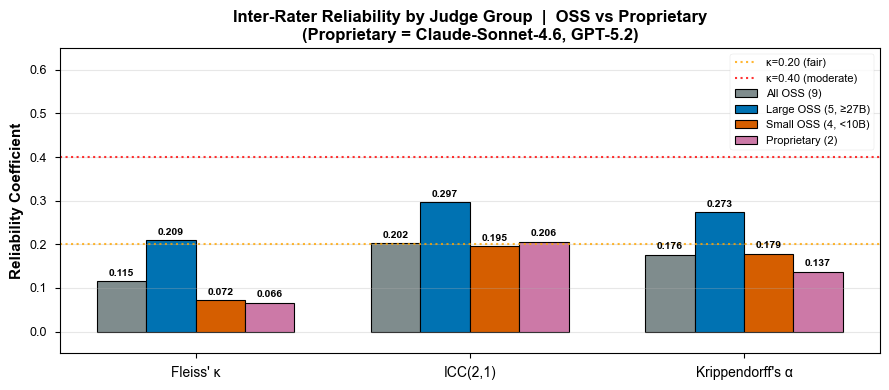

Fleiss' κ               All OSS (9) =0.115  Large OSS (5=0.209  Small OSS (4=0.072  Proprietary =0.066
ICC(2,1)                All OSS (9) =0.202  Large OSS (5=0.297  Small OSS (4=0.195  Proprietary =0.206
Krippendorff's α        All OSS (9) =0.176  Large OSS (5=0.273  Small OSS (4=0.179  Proprietary =0.137


In [6]:
# ── Figure C: IRR grouped bar chart ──────────────────────────────────────────
COL_PRIV = '#CC79A7'   # Wong reddish-purple — proprietary judges

irr_data = {
    "Fleiss' κ":         [irr['fleiss_all'],  irr['fleiss_big'],  irr['fleiss_small'],  irr['fleiss_priv']],
    'ICC(2,1)':          [irr['icc_all'],     irr['icc_big'],     irr['icc_small'],     irr['icc_priv']],
    "Krippendorff's α": [irr['kripp_all'],   irr['kripp_big'],   irr['kripp_small'],   irr['kripp_priv']],
}
groups       = ['All OSS (9)', 'Large OSS (5, ≥27B)', 'Small OSS (4, <10B)', 'Proprietary (2)']
group_colors = ['#7f8c8d', COL_LARGE, COL_SMALL, COL_PRIV]

x     = np.arange(len(irr_data))
n_grp = len(groups)
width = 0.18

fig, ax = plt.subplots(figsize=(9, 4))
for i, (grp, col) in enumerate(zip(groups, group_colors)):
    vals   = [irr_data[m][i] for m in irr_data]
    offset = (i - n_grp / 2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width, label=grp, color=col,
                    edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.axhline(y=0.20, color='orange', linestyle=':', linewidth=1.5,
           alpha=0.8, label='κ=0.20 (fair)')
ax.axhline(y=0.40, color='red',    linestyle=':', linewidth=1.5,
           alpha=0.8, label='κ=0.40 (moderate)')

ax.set_xticks(x)
ax.set_xticklabels(list(irr_data.keys()), fontsize=10)
ax.set_ylabel('Reliability Coefficient', fontweight='bold')
ax.set_title('Inter-Rater Reliability by Judge Group  |  OSS vs Proprietary\n'
             '(Proprietary = Claude-Sonnet-4.6, GPT-5.2)', fontweight='bold')
ax.set_ylim(-0.05, 0.65)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figC_irr_metrics.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figC_irr_metrics.png', dpi=DPI, bbox_inches='tight')
plt.show()

for m, vals in irr_data.items():
    print(f'{m:22s}  ' + '  '.join(f'{g[:12]:12s}={v:.3f}' for g, v in zip(groups, vals)))


---
## Figure D — Severity Calibration

In [7]:
# ── Load severity calibration ─────────────────────────────────────────────────
with open(BIAS_DIR / 'severity_calibration.json') as f:
    sev = json.load(f)

# 8 primary OSS judges only (exclude Qwen3-0.6B and any private/proprietary judges)
PRIMARY_8 = [j for j in LARGE + SMALL if j != 'Qwen3-0.6B']

sev_rows = []
for judge, info in sev['judge_severity'].items():
    if judge not in PRIMARY_8:
        continue   # skip private judges and Qwen3-0.6B
    sev_rows.append({
        'judge':          judge,
        'severity':       info['severity_estimate'],
        'std':            info['std'],
        'n':              info['n_ratings'],
        'group':          'Large' if judge in LARGE else 'Small',
        'interpretation': info['interpretation'],
    })
sev_df = pd.DataFrame(sev_rows).sort_values('severity', ascending=False)
print(f'{len(sev_df)} primary judges loaded')
sev_df

8 primary judges loaded


,judge,severity,std,n,group,interpretation
0,DeepSeek-V3-685B,0.1833,0.3948,840,Large,lenient (scores above consensus)
4,Qwen3-32B,0.1643,0.3983,770,Large,lenient (scores above consensus)
2,Llama-3.3-70B,0.0560,0.3740,840,Large,lenient (scores above consensus)
3,Gemma-3-27B,0.0322,0.4033,838,Large,well-calibrated (near consensus)
1,Kimi-K2-1T,-0.0381,0.4551,840,Large,well-calibrated (near consensus)
6,Llama-3.2-3B,-0.1263,0.5229,834,Small,severe (scores below consensus)
5,Llama-3.1-8B,-0.1977,0.5036,832,Small,severe (scores below consensus)
7,Qwen2.5-7B,-0.3783,0.5694,826,Small,severe (scores below consensus)


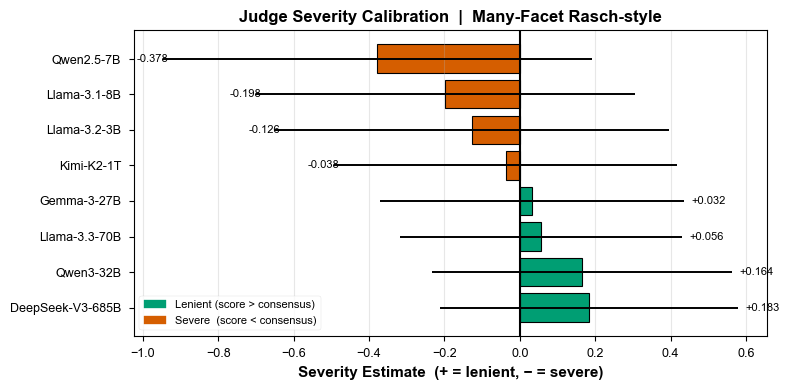

Large mean: +0.0781
Small mean: -0.2337
Gap:        +0.3118 (out of raw score gap 0.511 → 61% is severity)


In [8]:
# ── Figure D: Severity calibration horizontal bar ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = [COL_LARGE if g == 'Large' else COL_SMALL for g in sev_df['group']]
# Positive = lenient (blue), Negative = severe (red)
bar_cols = [COL_OK if v >= 0 else COL_FAIL for v in sev_df['severity']]

bars = ax.barh(sev_df['judge'], sev_df['severity'],
               xerr=sev_df['std'], color=bar_cols,
               edgecolor='black', linewidth=0.8, capsize=3)
ax.axvline(x=0, color='black', linewidth=1.5)

# Group brackets
for bar, (_, row) in zip(bars, sev_df.iterrows()):
    sign = '+' if row['severity'] >= 0 else ''
    xpos = row['severity'] + (row['std'] + 0.02 if row['severity'] >= 0 else -row['std'] - 0.07)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f"{sign}{row['severity']:.3f}",
            va='center', fontsize=8)

ax.legend(handles=[
    mpatches.Patch(color=COL_OK,   label='Lenient (score > consensus)'),
    mpatches.Patch(color=COL_FAIL, label='Severe  (score < consensus)'),
], fontsize=8)
ax.set_xlabel('Severity Estimate  (+ = lenient, − = severe)', fontweight='bold')
ax.set_title('Judge Severity Calibration  |  Many-Facet Rasch-style', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figD_severity.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figD_severity.png', dpi=DPI, bbox_inches='tight')
plt.show()

gap = sev['model_size_gap']
print(f"Large mean: {gap['big_mean_deviation']:+.4f}")
print(f"Small mean: {gap['small_mean_deviation']:+.4f}")
print(f"Gap:        {gap['gap']:+.4f} (out of raw score gap 0.511 → {gap['gap']/0.511:.0%} is severity)")

---
## Figure E — Temperature Stability

In [9]:
# ── Load temperature data ────────────────────────────────────────────────────
with open(BIAS_DIR / 'test2_temperature.json') as f:
    temp_data = json.load(f)
print(f'{len(temp_data)} tasks loaded')
print('Keys:', list(temp_data[0].keys()))

15 tasks loaded
Keys: ['task', 'temp_0.0', 'temp_0.5', 'temp_1.0']


Perfect rates: {0.0: '100.0%', 0.5: '53.3%', 1.0: '26.7%'}
Mean variance: {0.0: '0.000', 0.5: '0.120', 1.0: '0.253'}


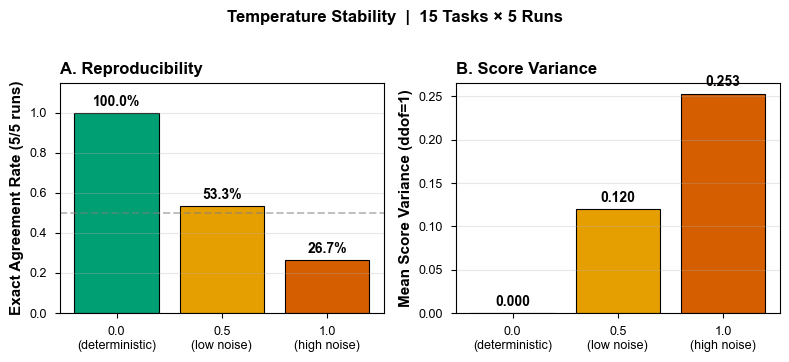

In [10]:
# ── Figure E: Temperature stability ─────────────────────────────────────────
temps = [0.0, 0.5, 1.0]
perfect_rates, mean_vars = [], []
for t in temps:
    key = f'temp_{t}'
    all_scores = [r[key] for r in temp_data if key in r and r[key]]
    perfect_rates.append(sum(1 for s in all_scores if len(set(s))==1) / len(all_scores) if all_scores else 0)
    mean_vars.append(float(np.mean([np.var(s, ddof=1) for s in all_scores if len(s)>1])) if all_scores else 0)

print('Perfect rates:', dict(zip(temps, [f"{r:.1%}" for r in perfect_rates])))
print('Mean variance:', dict(zip(temps, [f"{v:.3f}" for v in mean_vars])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
bar_cols = [COL_OK, COL_WARM, COL_FAIL]
temp_labels = ['0.0\n(deterministic)', '0.5\n(low noise)', '1.0\n(high noise)']

# Panel A: perfect agreement rate
ax1.bar(temp_labels, perfect_rates, color=bar_cols, edgecolor='black', linewidth=0.8)
for x, v in enumerate(perfect_rates):
    ax1.text(x, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Exact Agreement Rate (5/5 runs)', fontweight='bold')
ax1.set_title('A. Reproducibility', fontweight='bold', loc='left')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

# Panel B: mean variance
ax2.bar(temp_labels, mean_vars, color=bar_cols, edgecolor='black', linewidth=0.8)
for x, v in enumerate(mean_vars):
    ax2.text(x, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel('Mean Score Variance (ddof=1)', fontweight='bold')
ax2.set_title('B. Score Variance', fontweight='bold', loc='left')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Temperature Stability  |  15 Tasks × 5 Runs', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figE_temperature.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figE_temperature.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure F — Positional Bias

In [11]:
# ── Load positional bias data ────────────────────────────────────────────────
with open(BIAS_DIR / 'test4_positional.json') as f:
    pos_data = json.load(f)

consistent   = sum(1 for r in pos_data if r.get('consistent') is True)
inconsistent = sum(1 for r in pos_data if r.get('consistent') is False)
no_decision  = sum(1 for r in pos_data if r.get('consistent') is None)
total_valid  = consistent + inconsistent
print(f'Total: {len(pos_data)} | Consistent: {consistent} | Flipped: {inconsistent} | No decision: {no_decision}')
print(f'Flip rate: {inconsistent/total_valid:.1%}')

Total: 30 | Consistent: 18 | Flipped: 10 | No decision: 2
Flip rate: 35.7%


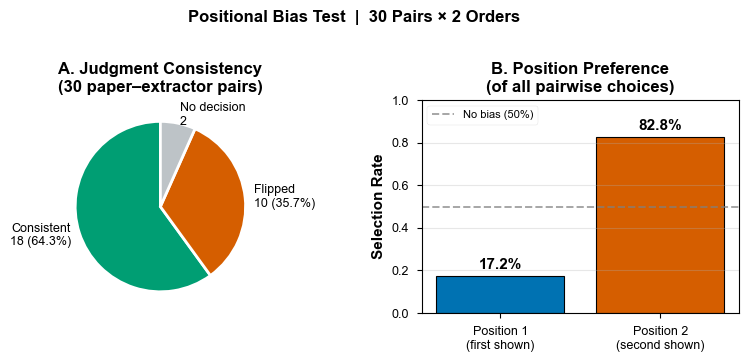

Position 1 (first shown): 17.2% (10/58)
Position 2 (second shown): 82.8% (48/58)
NOTE: Flip rate (35.7%) and position bias (82.8%) are different metrics:
  Flip rate = fraction of pairs where winner changes across orders
  Position bias = fraction of all choices that favored the 2nd-shown option


In [12]:
# ── Figure F: Positional bias ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

# Panel A: pie / donut of consistent vs flipped
wedge_vals  = [consistent, inconsistent, no_decision]
wedge_cols  = [COL_OK, COL_FAIL, '#bdc3c7']
wedge_labs  = [f'Consistent\n{consistent} ({consistent/total_valid:.1%})',
               f'Flipped\n{inconsistent} ({inconsistent/total_valid:.1%})',
               f'No decision\n{no_decision}']
ax1.pie(wedge_vals, labels=wedge_labs, colors=wedge_cols,
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops={'fontsize': 9})
ax1.set_title('A. Judgment Consistency\n(30 paper–extractor pairs)', fontweight='bold')

# Panel B: CORRECT position preference
# order_a: A=position 1, B=position 2
# order_b: B=position 1, A=position 2  (extractions are swapped)
pos1_choices = 0
pos2_choices = 0
for r in pos_data:
    ca = r.get('order_a_choice')  # 'A'→pos1, 'B'→pos2
    cb = r.get('order_b_choice')  # 'B'→pos1, 'A'→pos2
    if ca == 'A':  pos1_choices += 1
    elif ca == 'B': pos2_choices += 1
    if cb == 'B':  pos1_choices += 1   # B presented first in order_b = position 1
    elif cb == 'A': pos2_choices += 1  # A presented second in order_b = position 2

total_choices = pos1_choices + pos2_choices
p1 = pos1_choices / total_choices if total_choices else 0.5
p2 = 1 - p1

ax2.bar(['Position 1\n(first shown)', 'Position 2\n(second shown)'],
        [p1, p2], color=[COL_LARGE, COL_SMALL], edgecolor='black', linewidth=0.8)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='No bias (50%)')
for x, v in enumerate([p1, p2]):
    ax2.text(x, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Selection Rate', fontweight='bold')
ax2.set_title('B. Position Preference\n(of all pairwise choices)', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Positional Bias Test  |  30 Pairs × 2 Orders', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figF_positional.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figF_positional.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f'Position 1 (first shown): {p1:.1%} ({pos1_choices}/{total_choices})')
print(f'Position 2 (second shown): {p2:.1%} ({pos2_choices}/{total_choices})')
print(f'NOTE: Flip rate ({inconsistent/total_valid:.1%}) and position bias ({p2:.1%}) are different metrics:')
print('  Flip rate = fraction of pairs where winner changes across orders')
print('  Position bias = fraction of all choices that favored the 2nd-shown option')


---
## Figure F2 — Multi-Judge Positional Bias (All Judges × 30 Papers)

**3 panels:**
- **A** — 2-way pairwise consistency (DeepSeek-V3 vs Kimi-K2; 50% = chance)
- **B** — 4-way full-ranking consistency (all 4 extractors; 25% = random)
- **C** — Top-choice flip rate when presentation order is swapped

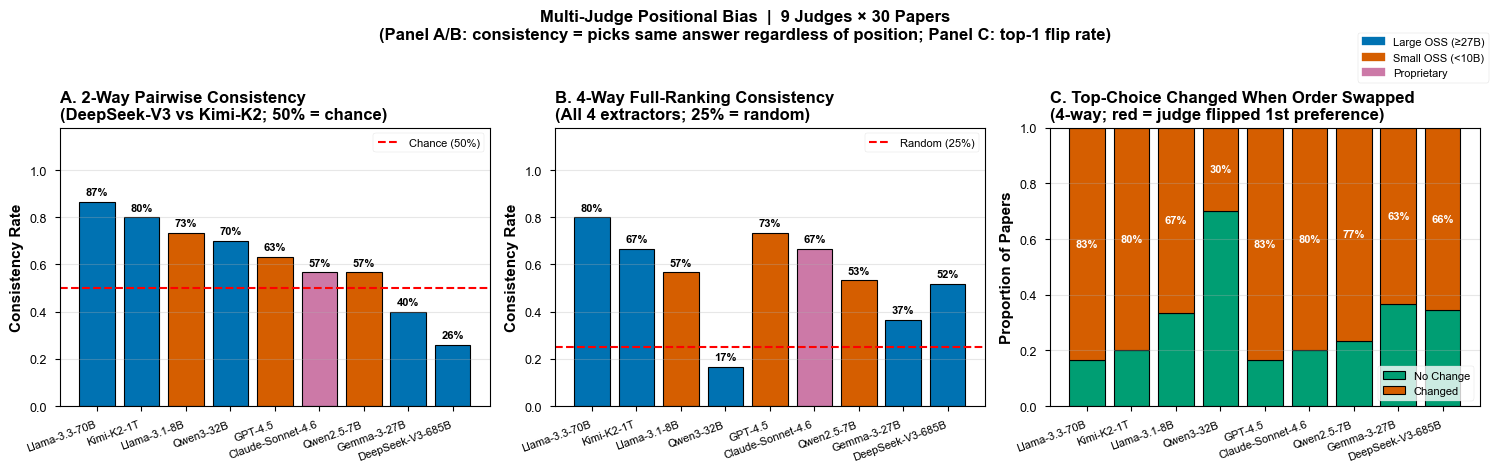

Judges: ['Llama-3.3-70B', 'Kimi-K2-1T', 'Llama-3.1-8B', 'Qwen3-32B', 'GPT-4.5', 'Claude-Sonnet-4.6', 'Qwen2.5-7B', 'Gemma-3-27B', 'DeepSeek-V3-685B']
  Llama-3.3-70B              2-way=87%  4-way=80%  changed=83%
  Kimi-K2-1T                 2-way=80%  4-way=67%  changed=80%
  Llama-3.1-8B               2-way=73%  4-way=57%  changed=67%
  Qwen3-32B                  2-way=70%  4-way=17%  changed=30%
  GPT-4.5                    2-way=63%  4-way=73%  changed=83%
  Claude-Sonnet-4.6          2-way=57%  4-way=67%  changed=80%
  Qwen2.5-7B                 2-way=57%  4-way=53%  changed=77%
  Gemma-3-27B                2-way=40%  4-way=37%  changed=63%
  DeepSeek-V3-685B           2-way=26%  4-way=52%  changed=66%


In [13]:
# ── Figure F2: Multi-judge positional bias (3 panels) ────────────────────────
with open(BIAS_DIR / 'test4_positional_multi_judge.json') as f:
    mj_data = json.load(f)

COL_PRIV  = '#CC79A7'   # Wong reddish-purple — proprietary judges
LARGE_J   = ['DeepSeek-V3-685B', 'Kimi-K2-1T', 'Llama-3.3-70B', 'Gemma-3-27B', 'Qwen3-32B']
SMALL_J   = ['Llama-3.1-8B', 'Llama-3.2-3B', 'Qwen2.5-7B']
PRIVATE_J = ['Claude-Sonnet-4.6', 'GPT-5.2']
EXCL_MJ   = {'Llama-3.2-3B', 'DeepSeek-V3'}   # old OpenRouter artifact → use DeepSeek-V3-685B

# Collect all judges with at least 1 valid result
all_j = set()
for r in mj_data:
    all_j.update(r['test_a'].keys())
    all_j.update(r['test_b']['judges'].keys())

def rate2w(j):
    n_c = sum(1 for r in mj_data
              if isinstance(r['test_a'].get(j), dict)
              and r['test_a'][j].get('consistent') is True)
    n_i = sum(1 for r in mj_data
              if isinstance(r['test_a'].get(j), dict)
              and r['test_a'][j].get('consistent') is False)
    total = n_c + n_i
    return n_c / total if total else -1

def rate4w(j):
    n_c = sum(1 for r in mj_data
              if isinstance(r['test_b']['judges'].get(j), dict)
              and r['test_b']['judges'][j].get('consistent') is True)
    n_i = sum(1 for r in mj_data
              if isinstance(r['test_b']['judges'].get(j), dict)
              and r['test_b']['judges'][j].get('consistent') is False)
    total = n_c + n_i
    return n_c / total if total else -1

# Build sorted judge list (sort by 2-way consistency, descending)
mj_judges = sorted(
    [j for j in all_j if j not in EXCL_MJ and rate2w(j) >= 0],
    key=rate2w, reverse=True
)

def judge_color(j):
    if j in LARGE_J:   return COL_LARGE
    if j in PRIVATE_J: return COL_PRIV
    return COL_SMALL

rates_2w = [rate2w(j) for j in mj_judges]
rates_4w = [rate4w(j) for j in mj_judges]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel A: 2-way pairwise consistency rate ──────────────────────────────────
ax = axes[0]
bar_cols = [judge_color(j) for j in mj_judges]
bars = ax.bar(range(len(mj_judges)), rates_2w, color=bar_cols, edgecolor='black', linewidth=0.8)
ax.axhline(0.50, color='red', linestyle='--', linewidth=1.5, label='Chance (50%)')
for i, v in enumerate(rates_2w):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.18)
ax.set_xticks(range(len(mj_judges)))
ax.set_xticklabels(mj_judges, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Consistency Rate', fontweight='bold')
ax.set_title('A. 2-Way Pairwise Consistency\n(DeepSeek-V3 vs Kimi-K2; 50% = chance)',
             fontweight='bold', loc='left')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel B: 4-way full-ranking consistency rate ──────────────────────────────
ax = axes[1]
bars = ax.bar(range(len(mj_judges)), rates_4w, color=bar_cols, edgecolor='black', linewidth=0.8)
ax.axhline(0.25, color='red', linestyle='--', linewidth=1.5, label='Random (25%)')
for i, v in enumerate(rates_4w):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.18)
ax.set_xticks(range(len(mj_judges)))
ax.set_xticklabels(mj_judges, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Consistency Rate', fontweight='bold')
ax.set_title('B. 4-Way Full-Ranking Consistency\n(All 4 extractors; 25% = random)',
             fontweight='bold', loc='left')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel C: Stacked CHANGED / NO CHANGE (top-1 pick across order swap) ───────
ax = axes[2]
changed_rates, nochange_rates = [], []
for j in mj_judges:
    n_changed = n_nochange = 0
    for r in mj_data:
        jd = r['test_b']['judges'].get(j, {})
        p1 = jd.get('order1_pick_label')
        p2 = jd.get('order2_pick_label')
        if p1 is not None and p2 is not None:
            if p1 != p2:
                n_changed += 1
            else:
                n_nochange += 1
    total = n_changed + n_nochange
    changed_rates.append(n_changed / total if total else 0)
    nochange_rates.append(n_nochange / total if total else 0)

x = range(len(mj_judges))
ax.bar(x, nochange_rates, color=COL_OK,   edgecolor='black', linewidth=0.8, label='No Change')
ax.bar(x, changed_rates,  color=COL_FAIL, edgecolor='black', linewidth=0.8,
       bottom=nochange_rates, label='Changed')
for i, (nc, ch) in enumerate(zip(nochange_rates, changed_rates)):
    if ch > 0.04:
        ax.text(i, nc + ch / 2, f'{ch:.0%}', ha='center', va='center',
                fontweight='bold', fontsize=8, color='white')
ax.set_ylim(0, 1.0)
ax.set_xticks(list(x))
ax.set_xticklabels(mj_judges, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Proportion of Papers', fontweight='bold')
ax.set_title('C. Top-Choice Changed When Order Swapped\n(4-way; red = judge flipped 1st preference)',
             fontweight='bold', loc='left')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.3)

legend_patches = [
    mpatches.Patch(color=COL_LARGE, label='Large OSS (≥27B)'),
    mpatches.Patch(color=COL_SMALL, label='Small OSS (<10B)'),
    mpatches.Patch(color=COL_PRIV,  label='Proprietary'),
]
fig.legend(handles=legend_patches, loc='upper right', fontsize=8,
           bbox_to_anchor=(1.0, 1.0), framealpha=0.9)

fig.suptitle(
    f'Multi-Judge Positional Bias  |  {len(mj_judges)} Judges × 30 Papers\n'
    '(Panel A/B: consistency = picks same answer regardless of position; Panel C: top-1 flip rate)',
    fontweight='bold', y=1.04
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figF2_positional_multi_judge.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figF2_positional_multi_judge.png', dpi=DPI, bbox_inches='tight')
plt.show()

print('Judges:', mj_judges)
for j, r2, r4, ch in zip(mj_judges, rates_2w, rates_4w, changed_rates):
    print(f'  {j:25s}  2-way={r2:.0%}  4-way={r4:.0%}  changed={ch:.0%}')


---
## Figure G — Population Label Bias

In [14]:
# ── Load population bias data ────────────────────────────────────────────────
with open(BIAS_DIR / 'test5_population_bias.json') as f:
    pop_raw = json.load(f)

# Build per-population summary
pop_summary = []
for pid, info in pop_raw['per_population'].items():
    pop_summary.append({'id': pid, 'label': info['label'],
                        'mean': info['mean'], 'std': info['std'], 'n': info['n']})
pop_df = pd.DataFrame(pop_summary).sort_values('mean', ascending=True)
pop_df

,id,label,mean,std,n
2,P3,"White females, USA (age 45-65)",1.666667,1.0,9
1,P2,"Black males, USA (age 45-65)",2.333333,1.0,9
0,P1,"White males, USA (age 45-65)",2.666667,0.5,9
3,P4,"Elderly patients, USA (age ≥65)",3.000000,0.0,9
4,P5,"Adults, South Asia",3.000000,0.0,9
5,P6,"Children/adolescents, USA (age 6-17)",3.000000,0.0,7


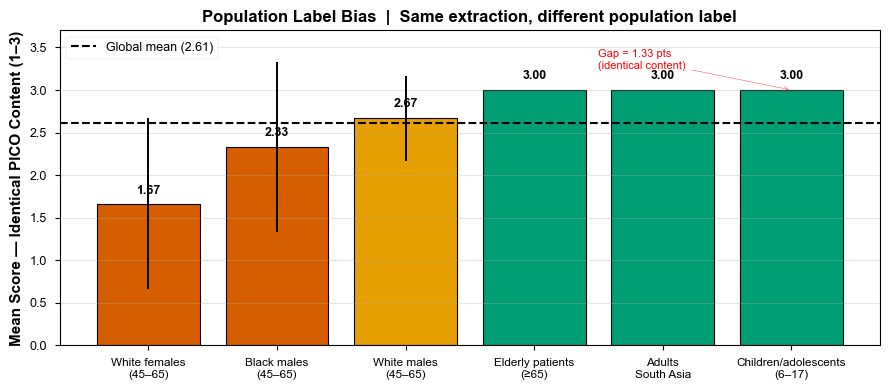

In [15]:
# ── Figure G: Population label bias ─────────────────────────────────────────
# EDIT: short_labels to change x-axis display
short_labels = [
    l.replace(', USA (age 45-65)', '\n(45–65)').replace(', USA (age ≥65)', '\n(≥65)')
     .replace(', USA (age 6-17)', '\n(6–17)').replace(', South Asia', '\nSouth Asia')
    for l in pop_df['label']
]
global_mean = pop_df['mean'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
# Colour bars by deviation from global mean
bar_colors = [COL_FAIL if m < global_mean - 0.1 else COL_OK if m > global_mean + 0.1
              else COL_WARM for m in pop_df['mean']]
bars = ax.bar(range(len(pop_df)), pop_df['mean'],
              yerr=pop_df['std'], color=bar_colors,
              edgecolor='black', linewidth=0.8, capsize=4)
ax.axhline(y=global_mean, color='black', linestyle='--', linewidth=1.5,
           label=f'Global mean ({global_mean:.2f})')
ax.set_xticks(range(len(pop_df)))
ax.set_xticklabels(short_labels, fontsize=8.5)
for bar, val in zip(bars, pop_df['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02 + 0.04,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_ylim(0, 3.7)
ax.set_ylabel('Mean Score — Identical PICO Content (1–3)', fontweight='bold')
ax.set_title('Population Label Bias  |  Same extraction, different population label', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Annotation for the biggest gap
lo, hi = pop_df['mean'].min(), pop_df['mean'].max()
ax.annotate(f'Gap = {hi-lo:.2f} pts\n(identical content)',
            xy=(len(pop_df)-1, hi), xytext=(len(pop_df)-2.5, hi+0.25),
            fontsize=8, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig(OUT_DIR / 'figG_population_bias.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figG_population_bias.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure H — Scale Sensitivity (Test 6)

In [16]:
# ── Load scale sensitivity data ──────────────────────────────────────────────
with open(BIAS_DIR / 'test6_scale_sensitivity.json') as f:
    scale_raw = json.load(f)

results = scale_raw['results']
# Build per (judge, scale) normalized overall score
judge_scale = defaultdict(lambda: defaultdict(list))
for r in results:
    if not isinstance(r, dict): continue
    norm = r.get('normalized') or {}
    v = norm.get('overall')
    if v is not None:
        judge_scale[r['judge']][r['scale']].append(v)

scales = [3, 5, 10]
judges_s6 = sorted(judge_scale.keys())
scale_summary = []
for j in judges_s6:
    row = {'judge': j}
    vals = []
    for s in scales:
        m = float(np.mean(judge_scale[j][s])) if judge_scale[j][s] else None
        row[f'scale_{s}'] = m
        if m is not None: vals.append(m)
    row['gap'] = max(vals) - min(vals) if len(vals) > 1 else None
    scale_summary.append(row)
scale_df = pd.DataFrame(scale_summary).sort_values('gap')
scale_df

,judge,scale_3,scale_5,scale_10,gap
0,Claude-Sonnet-4.6,0.566667,0.558333,0.564815,0.008333
4,Qwen3-32B,0.691667,0.666667,0.659259,0.032407
1,DeepSeek-V3-685B,0.541667,0.575000,0.670370,0.128704
2,GPT-5.2,0.500000,0.645833,0.631481,0.145833
3,Llama-3.3-70B,0.508333,0.725000,0.707407,0.216667


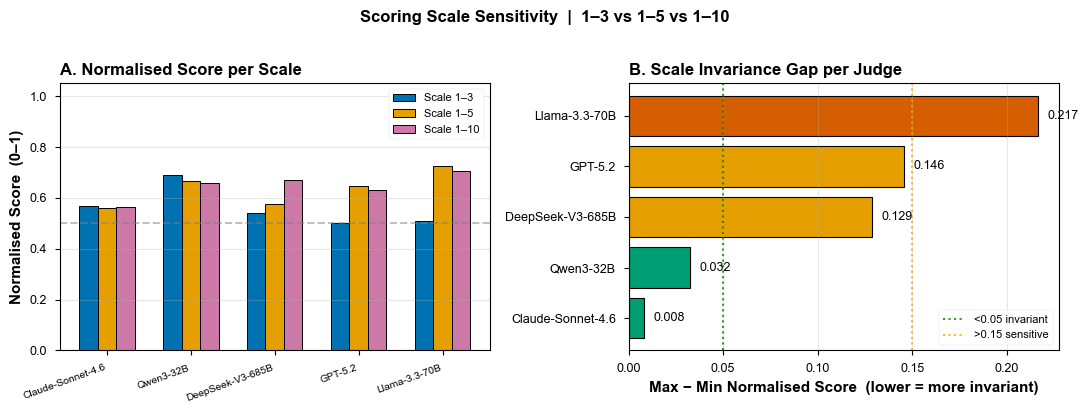

In [17]:
# ── Figure H: Scale sensitivity ───────────────────────────────────────────────
scale_colors = {'3': '#0072B2', '5': '#E69F00', '10': '#CC79A7'}
x   = np.arange(len(scale_df))
w   = 0.22

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: grouped bars per judge per scale
for i, s in enumerate(scales):
    col = f'scale_{s}'
    vals = scale_df[col].fillna(0).tolist()
    offset = (i - 1) * w
    ax1.bar(x + offset, vals, w, label=f'Scale 1–{s}',
            color=list(scale_colors.values())[i], edgecolor='black', linewidth=0.7)

ax1.set_xticks(x)
ax1.set_xticklabels(scale_df['judge'], fontsize=7.5, rotation=20, ha='right')
ax1.set_ylabel('Normalised Score  (0–1)', fontweight='bold')
ax1.set_title('A. Normalised Score per Scale', fontweight='bold', loc='left')
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Panel B: gap (max - min normalised score per judge)
gap_cols = [COL_OK if g < 0.05 else COL_WARM if g < 0.15 else COL_FAIL
            for g in scale_df['gap'].fillna(0)]
bars = ax2.barh(scale_df['judge'], scale_df['gap'].fillna(0),
                color=gap_cols, edgecolor='black', linewidth=0.8)
ax2.axvline(x=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.8, label='<0.05 invariant')
ax2.axvline(x=0.15, color='orange', linestyle=':', linewidth=1.5, alpha=0.8, label='>0.15 sensitive')
for bar, val in zip(bars, scale_df['gap'].fillna(0)):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.set_xlabel('Max − Min Normalised Score  (lower = more invariant)', fontweight='bold')
ax2.set_title('B. Scale Invariance Gap per Judge', fontweight='bold', loc='left')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Scoring Scale Sensitivity  |  1–3 vs 1–5 vs 1–10', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figH_scale_sensitivity.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figH_scale_sensitivity.png', dpi=DPI, bbox_inches='tight')
plt.show()


---
## Figure I — Cross-Judge Score Heatmap (extractor × judge)

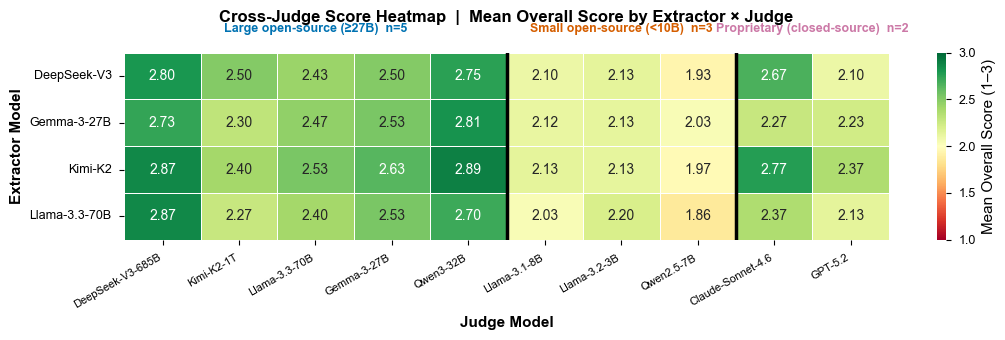

Columns: ['DeepSeek-V3-685B', 'Kimi-K2-1T', 'Llama-3.3-70B', 'Gemma-3-27B', 'Qwen3-32B', 'Llama-3.1-8B', 'Llama-3.2-3B', 'Qwen2.5-7B', 'Claude-Sonnet-4.6', 'GPT-5.2']
Large=5 | Small=3 | Proprietary=2


In [18]:
# ── Figure I: Heatmap of mean overall score, extractor × judge ───────────────
# Groups: Large (≥27B open-source) | Small (<10B, excl. Qwen3-0.6B) | Proprietary (Claude/GPT)
LARGE_J   = ['DeepSeek-V3-685B', 'Kimi-K2-1T', 'Llama-3.3-70B', 'Gemma-3-27B', 'Qwen3-32B']
SMALL_J   = ['Llama-3.1-8B', 'Llama-3.2-3B', 'Qwen2.5-7B']          # Qwen3-0.6B excluded (88% JSON failure)
PRIVATE_J = ['Claude-Sonnet-4.6', 'GPT-5.2']                          # Gemini skipped (API quota exhausted)

COL_PRIV  = '#CC79A7'   # Wong reddish-purple — proprietary judges

overall_df = df[df.dim == 'overall'].copy()
pivot = overall_df.groupby(['extractor', 'judge'])['score'].mean().unstack()

# Build ordered column list: Large | Small | Proprietary (skip missing)
col_order = (
    [j for j in LARGE_J   if j in pivot.columns] +
    [j for j in SMALL_J   if j in pivot.columns] +
    [j for j in PRIVATE_J if j in pivot.columns]
)
pivot = pivot[col_order]

n_large   = sum(1 for j in col_order if j in LARGE_J)
n_small   = sum(1 for j in col_order if j in SMALL_J)
n_private = sum(1 for j in col_order if j in PRIVATE_J)

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=1.0, vmax=3.0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mean Overall Score (1–3)'})

# Group boundary lines
ax.axvline(x=n_large, color='black', linewidth=2.5)
if n_private > 0:
    ax.axvline(x=n_large + n_small, color='black', linewidth=2.5)

# Group labels above the heatmap
def group_label(ax, x_start, width, text, color):
    if width > 0:
        ax.text(x_start + width / 2, -0.45, text,
                ha='center', fontsize=9, fontweight='bold', color=color,
                transform=ax.transData, clip_on=False)

group_label(ax, 0,               n_large,   f'Large open-source (≥27B)  n={n_large}',     COL_LARGE)
group_label(ax, n_large,         n_small,   f'Small open-source (<10B)  n={n_small}',     COL_SMALL)
group_label(ax, n_large+n_small, n_private, f'Proprietary (closed-source)  n={n_private}', COL_PRIV)

ax.set_xlabel('Judge Model', fontweight='bold')
ax.set_ylabel('Extractor Model', fontweight='bold')
ax.set_title('Cross-Judge Score Heatmap  |  Mean Overall Score by Extractor × Judge',
             fontweight='bold', pad=22)

plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figI_heatmap.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figI_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f'Columns: {list(pivot.columns)}')
print(f'Large={n_large} | Small={n_small} | Proprietary={n_private}')
if n_private == 0:
    print('NOTE: Proprietary columns appear after running run_private_cross_judge.py')


---
## Supplementary Figure S1 — Q1: Judge Score Distributions per Extractor

Friedman test: block = paper, treatment = judge.  
Confirms judge identity (not extraction quality) is the dominant source of score variance across extractors.

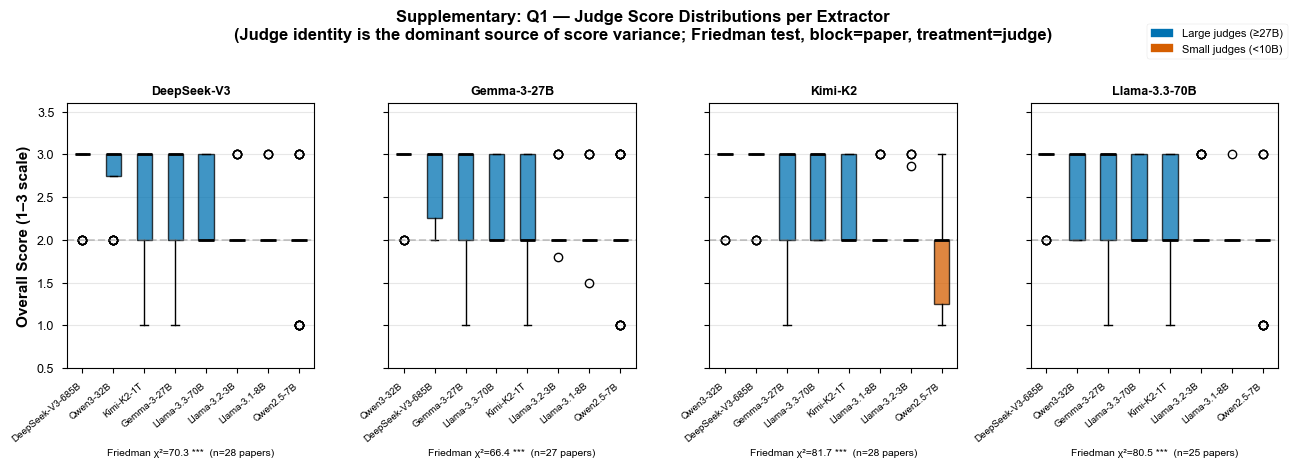

In [19]:
# ── Supplementary Figure: Q1 Judge score distributions per extractor ──────────
# Friedman Q1: For each extractor, do the 8 judges assign significantly
# different scores to the same extraction?  (block=paper, treatment=judge)
from scipy import stats as scipy_stats

PRIMARY_JUDGES = [j for j in LARGE + SMALL if j != 'Qwen3-0.6B']
extractors     = sorted(df['extractor'].unique())

fig, axes = plt.subplots(1, len(extractors), figsize=(13, 4.5), sharey=True)

for i, ext in enumerate(extractors):
    ax = axes[i]
    ext_df = df[(df['extractor'] == ext) & (df['dim'] == 'overall')].copy()
    ext_df = ext_df[ext_df['judge'].isin(PRIMARY_JUDGES)]

    # Judge order: large first (sorted by mean desc), then small
    means = ext_df.groupby('judge')['score'].mean()
    large_order = sorted([j for j in LARGE if j in means.index], key=lambda j: -means[j])
    small_order = sorted([j for j in SMALL if j in means.index and j != 'Qwen3-0.6B'],
                         key=lambda j: -means[j])
    judge_order = large_order + small_order

    data_list = [ext_df[ext_df['judge'] == j]['score'].values for j in judge_order]
    bp = ax.boxplot(data_list, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2},
                    whiskerprops={'linewidth': 1}, capprops={'linewidth': 1})

    colors = [COL_LARGE if j in LARGE else COL_SMALL for j in judge_order]
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    ax.set_xticks(range(1, len(judge_order) + 1))
    ax.set_xticklabels(judge_order, rotation=40, ha='right', fontsize=7)
    ax.set_title(ext, fontweight='bold', fontsize=9)
    ax.set_ylim(0.5, 3.6)
    ax.axhline(2.0, color='gray', linestyle='--', alpha=0.4)
    ax.grid(axis='y', alpha=0.3)

    # Friedman test on complete blocks (papers where all judges scored)
    pivot = ext_df.pivot_table(index='pmid', columns='judge', values='score', aggfunc='mean')
    pivot = pivot[[j for j in judge_order if j in pivot.columns]].dropna()
    if len(pivot) >= 5 and pivot.shape[1] >= 3:
        stat, p = scipy_stats.friedmanchisquare(*[pivot[j].values for j in pivot.columns])
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        n_blocks = len(pivot)
        ax.set_xlabel(f'Friedman χ²={stat:.1f} {stars}  (n={n_blocks} papers)', fontsize=7.5)

axes[0].set_ylabel('Overall Score (1–3 scale)', fontweight='bold')

fig.suptitle(
    'Supplementary: Q1 — Judge Score Distributions per Extractor\n'
    '(Judge identity is the dominant source of score variance; '
    'Friedman test, block=paper, treatment=judge)',
    fontweight='bold', y=1.03
)
fig.legend(handles=[
    mpatches.Patch(color=COL_LARGE, label='Large judges (≥27B)'),
    mpatches.Patch(color=COL_SMALL, label='Small judges (<10B)'),
], loc='upper right', fontsize=8, bbox_to_anchor=(1.0, 1.01))

plt.tight_layout()
plt.savefig(OUT_DIR / 'figS_judge_variance_per_extractor.pdf', dpi=DPI, bbox_inches='tight')
plt.savefig(OUT_DIR / 'figS_judge_variance_per_extractor.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Save all figures summary

In [20]:
print('\nAll figures saved to:', OUT_DIR.resolve())
print()
for f in sorted(OUT_DIR.glob('fig*.p*')):
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<45}  {size_kb:>5} KB')


All figures saved to: /Users/chenyuli/Desktop/MedOS/BMI-Research/rwe-research/AMIA2026_Package/manuscript/figures

  figA_judge_scores.pdf                             34 KB
  figA_judge_scores.png                            224 KB
  figB_pico_dimensions.pdf                          28 KB
  figB_pico_dimensions.png                         125 KB
  figC_irr_metrics.pdf                              33 KB
  figC_irr_metrics.png                             174 KB
  figD_severity.pdf                                 29 KB
  figD_severity.png                                152 KB
  figE_temperature.pdf                              26 KB
  figE_temperature.png                             150 KB
  figF2_positional_multi_judge.pdf                  41 KB
  figF2_positional_multi_judge.png                 399 KB
  figF_positional.pdf                               30 KB
  figF_positional.png                              171 KB
  figG_population_bias.pdf                          31 KB
  figG_populat